# Credit Risk Prediction System

## Part A: Data acquisition and understanding

In [3]:
!pip install seaborn

In [4]:
!pip install scikit-learn

In [5]:
import pandas as pd
import numpy as np
#Visualisations
import matplotlib.pyplot as plt #for creating charts/graphs
import seaborn as sns #for higher-level plots

df = pd.read_csv("credit_risk_dataset.csv")

#Displaying shape
print("Dataset shape [rows, columns]:", df.shape)
                 

Dataset shape [rows, columns]: (32581, 12)


In [6]:
#Displaying columns
print("Columns:")
print(df.columns.tolist())

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [7]:
#Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
#describe
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
#Identifying missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
print("Columns with missing values:")
missing_summary

Columns with missing values:


,missing_count,missing_percent
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000


The dataset contains a mix of numeric and categorial features. And two columns `[loan_int_rate and person_emp_length]` contains missing values.

## PART B: Exploratory Data Analysis (EDA)

In [12]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (6, 4)

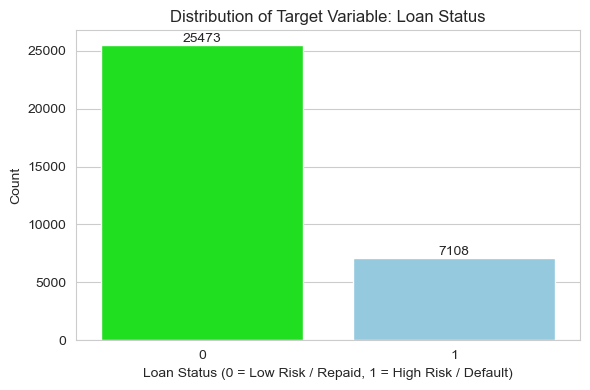

In [13]:
#Target variable distribution
plt.figure()
axes = sns.countplot(x='loan_status', hue='loan_status', data = df,
                     palette=['lime', 'skyblue'], legend=False)
plt.title('Distribution of Target Variable: Loan Status')
plt.xlabel('Loan Status (0 = Low Risk / Repaid, 1 = High Risk / Default)') #X-axis label
plt.ylabel('Count') #y-axis label

for p in axes.patches:
    axes.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                  ha='center', va='bottom') #horizontally centering the text and positioning text above the bar top
plt.tight_layout()
#Saving the chart as a png 
plt.savefig('target_distribution.png', dpi=110)
plt.show()

#Intepretation:
#The target classes are imbalanced (78% low-risk vs 22% high-risk). A naive model could reach 78% accuracy by just predicting the majority class, 
#so techniques like class weighing and metric like precision/recal/F1 should be considered when modelling.

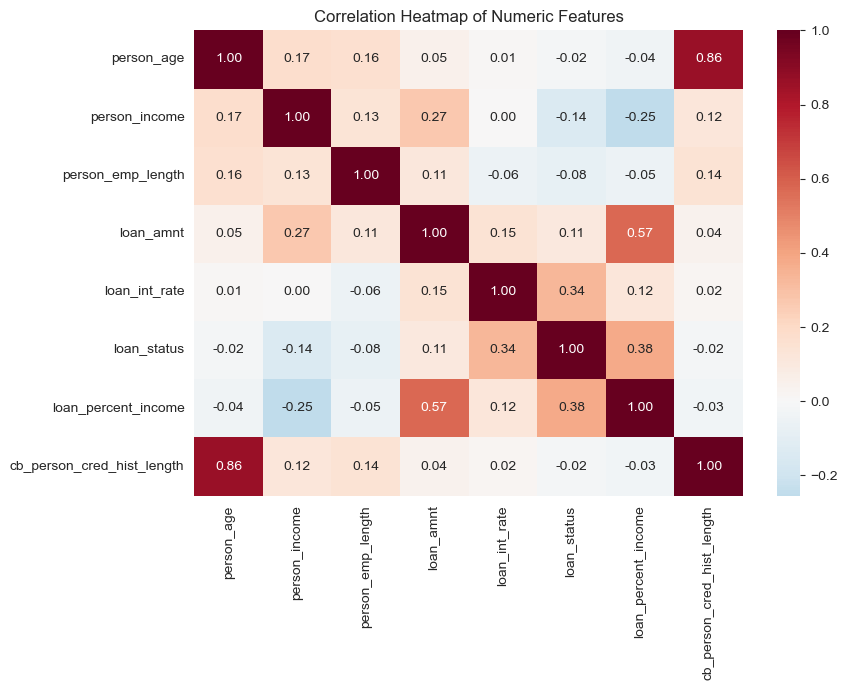

In [19]:
#Correlation heatmap
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f',cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=110)
plt.show()

#Interpretation:
#loan_percent_income and loan_int_rate show the strongest correlation with loan_status, suggesting they are useful predictors of default risk.
#person_age and cb_person_cred_hist_length are highly correlated (0.86), showing that redundant iformation [one could be dropped to reduce 
#multicollinearity]. Most other features show weak correlation with each other.

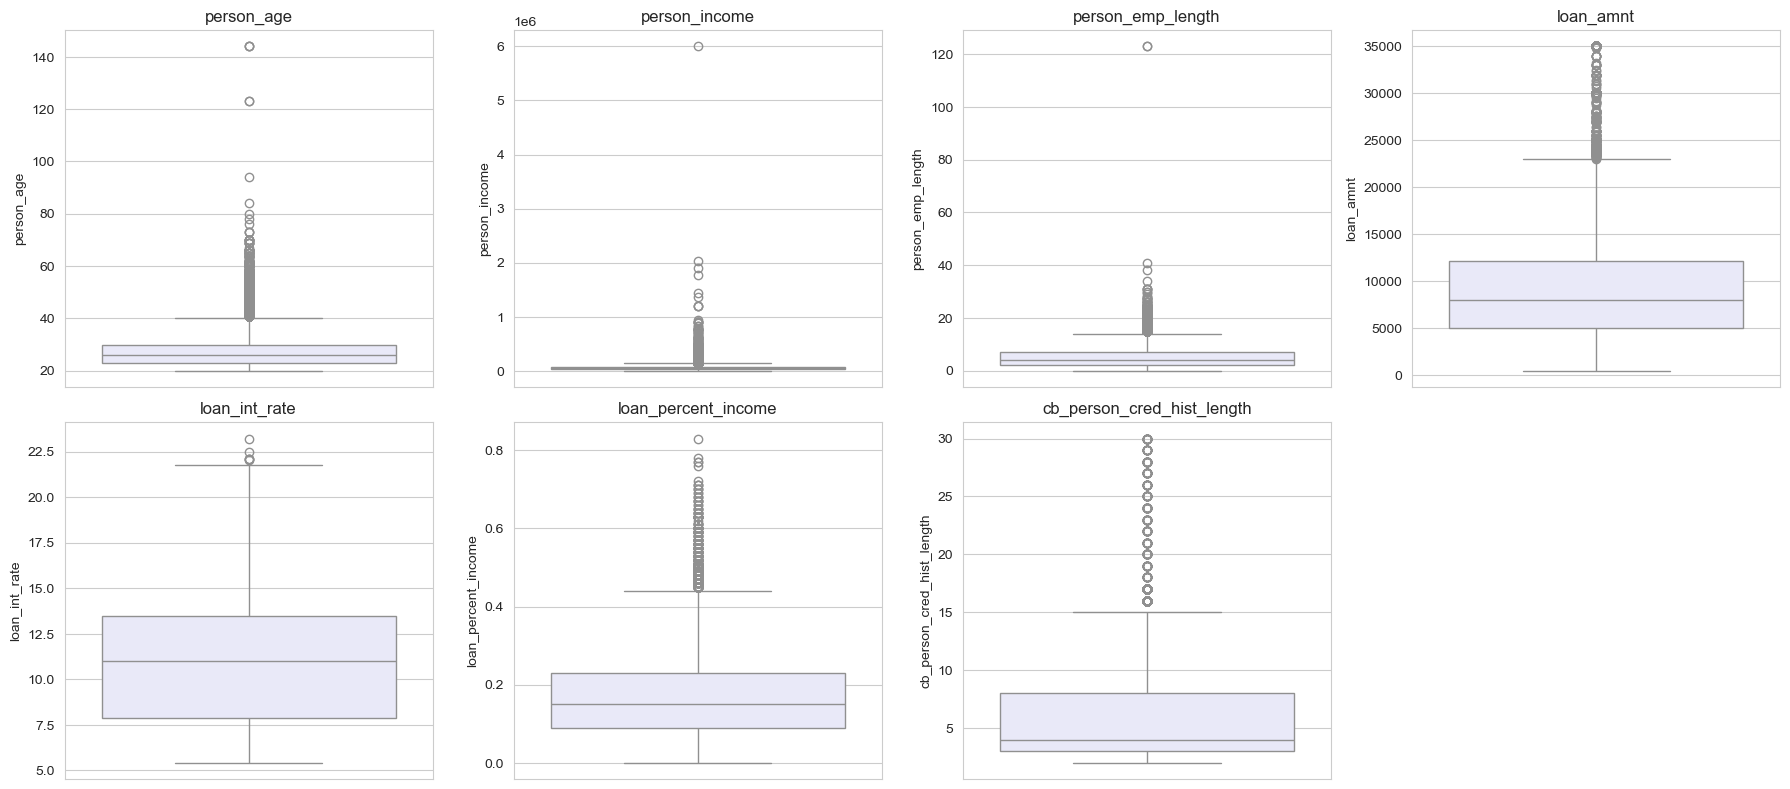

In [20]:
#Boxplots ofr outliers
numeric_cols =['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
              'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lavender')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=110)
plt.show()

#Interpretation
#Boxplots reveal significant outliers across several features, some of which appear to be data entry errors rather then genuine values (e.g person_age
#reaching 144 and person_emp_length reaching 123 years are not realistic). person_income also has extreme outliers (up to 6 000 000) far above the
#typical range. loan_amnt, loan_int_rate, and loan_percent_income show more convincing but still notable outliers and likely reflecting 
#higher-risk borrowers. These outliers should be investigated and addressed (e.g capped, removed,or treated as missing) before modelling 
#to avoid skewing results.

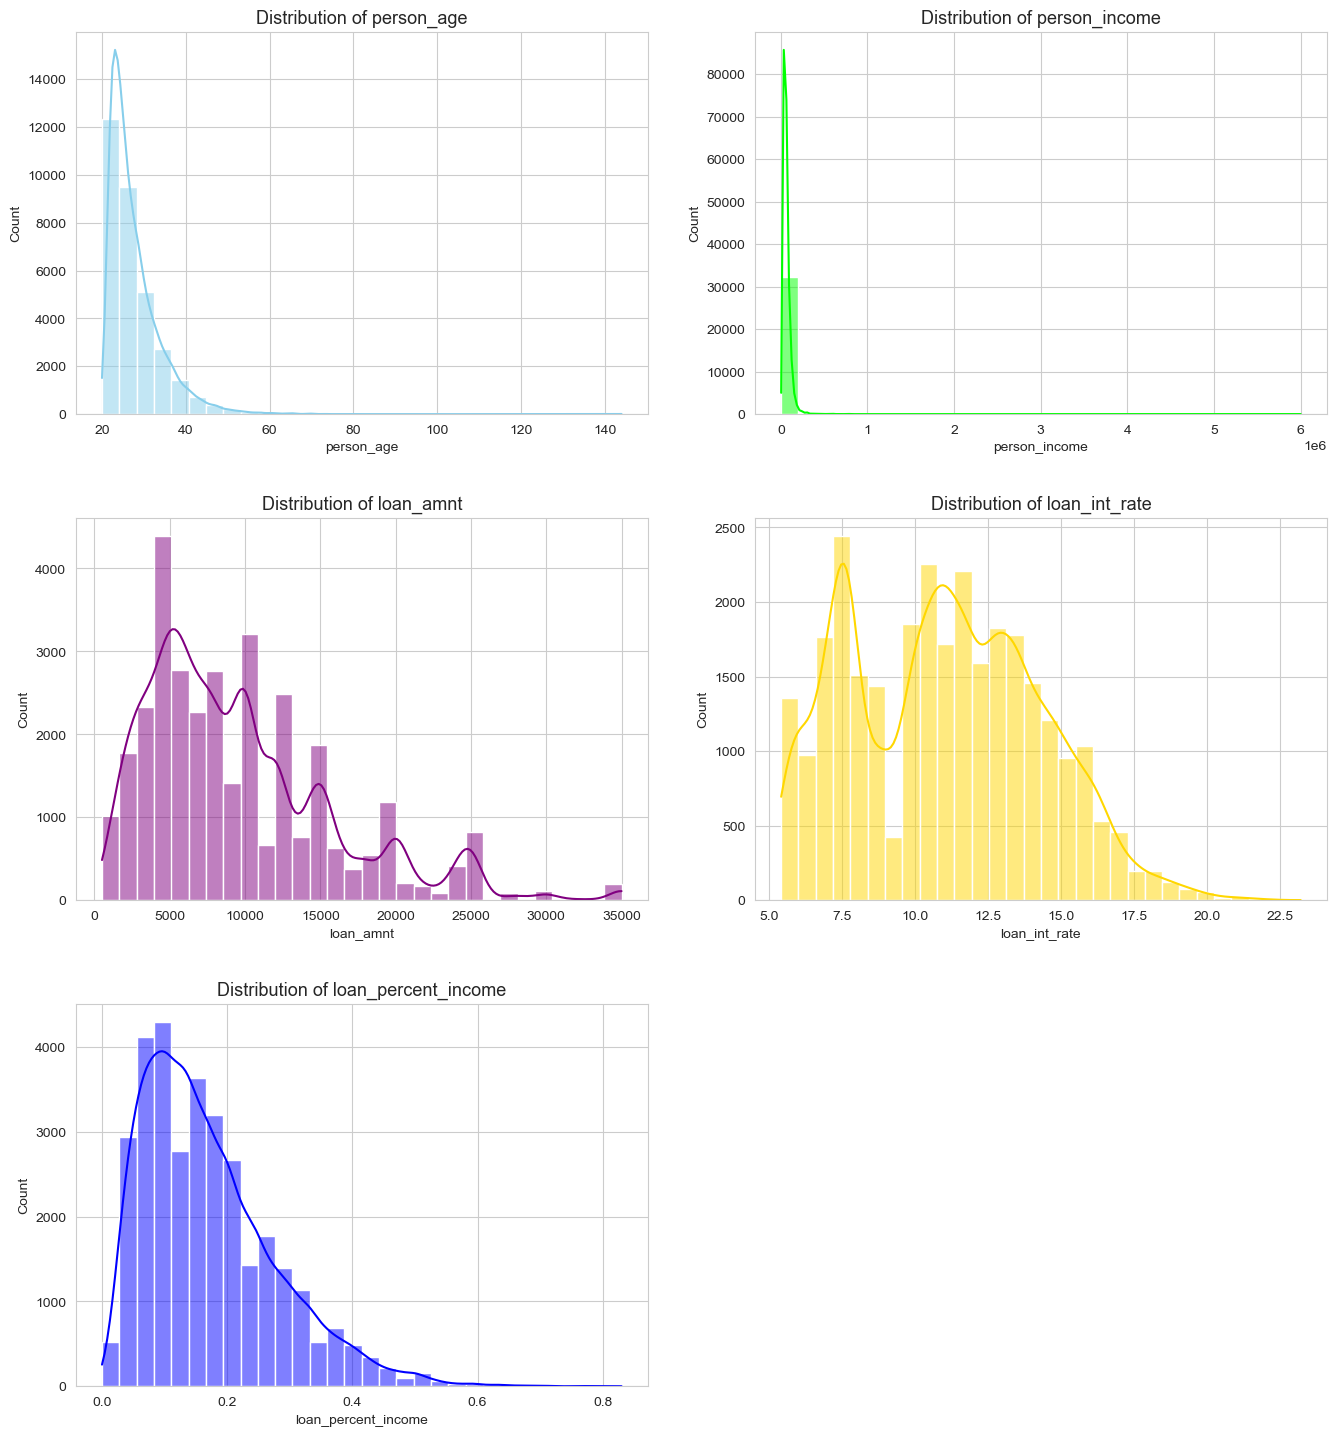

In [20]:
#Histograms of selected numerical features
selected_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
colors = ['skyblue', 'lime', 'purple', 'gold', 'blue']

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.histplot(df[col], bins=30, kde=True, color=colors[i], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

#Removing any unused empty subplot
for j in range(len(selected_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(pad=3.0)
plt.savefig('histograms_numeric_features.png', dpi=110)
plt.show()


#Interpretation
#Most selected features are right-skewed rather than normally distributed.
#person_income is extremely skewed with the vast majority of applicants earning well below the extreme high-income outliers. loan_amnt 
#and loan_percent_income are also right-skewed and showing that most loans are smaller relative to income with a tail of larger and higher-risk loans.
#loan_int_rate is closer to a normal/spread distribution. This skewnesssuggests log transformation or scaling may be useful for some features
#before modelling.

## PART C: Data Cleaning and Processing

## Handling missing values

In [27]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_percentage': missing_percentage})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percentage
person_emp_length,895,2.747000
loan_int_rate,3116,9.563856


## Handling missing values

`person_emp_length` has 895 missing values and `loan_int_rate` has 3116 missing values.

**Justification:**
- `person_emp_length` is assumed with the median since employment length is right-skewed and the median is robust to that skew/outliers compared to the mean.
- `loan_int_rate`, the interest rates are strongly tied to laon_grade (A = lowest risk/lowest rate, G = highest risk/highest rate), so imputing with the overall median would hide that relationship.


In [28]:
#imputing person_emp_length with the overall mediam
emp_length_median = df['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].fillna(emp_length_median)

#imputing loan_int_rate with the mediam interest rate per loan_grade
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining missing values:")
print(df.isnull().sum().sum())


Remaining missing values:
0


## Removing duplicates

In [29]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicates. New shape: {df.shape}")

Removed 165 duplicates. New shape: (32416, 12)


## Treating outliers
- `person_age`: maximum value of 144 (and other values above 100) is not a realistic human age.
- `person_emp_length`: maximum value of 123 years of employement which is impossible given the age range in the dataset.
- `person_income`: has some big values (up to 6 000 000) which are real but rare high earners, so we trat these with capping rather than removal since income can vary and removing row would lose valid applicants.


In [30]:
#Removing impossible values
before = df.shape[0]
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]
print(f"Rows removed as impossible outliers: {before - df.shape[0]}")

#Capping remaining outliers 
def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower=lower, upper=upper)
for col in ['person_income', 'loan_amnt', 'loan_int_rate', 'person_age', 'person_emp_length']:
    df[col] = cap_outliers_iqr(df[col])
df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate']].describe()
print("Shape after outlier treatment:", df.shape)

Rows removed as impossible outliers: 7
Shape after outlier treatment: (32409, 12)


## Encoding categorial variables

In [31]:
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df['loan_grade'] = df['loan_grade'].map(grade_map)

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (32409, 18)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21.0,9600,5.0,1,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
2,25.0,9600,1.0,2,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
3,23.0,65500,4.0,2,23125,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False
4,24.0,54400,8.0,2,23125,14.27,1,0.55,1,4,False,False,True,False,False,True,False,False
5,21.0,9900,2.0,0,2500,7.14,1,0.25,0,2,False,True,False,False,False,False,False,True


## Feature scaling 
transforming numeric features so they are on a comparable scale instead of leaving some in the thousands and others between 0 and 1.

In [16]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")

Number of features: 17


## Splitting dataset into training and testing sets (80/20)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape) 

Train shape: (25343, 17) Test shape: (6336, 17)


**Feature scaling** is necessary because it puts all numeric features on a similar scale instead of one ranging in the thousands and another between 0 and 1.
- Many algorithms use the raw numbers directly (in distance calculations (KNN, SVM) or gradientt based training. So without scaling a feature with naturally larger values (e.g income) can dominate the model just because of its size and not because it is more important.
- Scaling also helps regularised models penalise features failry and helps gradient descent converge faster.

## PART D: Principal Component Analysis (PCA)